# MNIST Activation Function Comparison (PyTorch)

This notebook trains two neural network models on the MNIST dataset:

- Model 1: ReLU activation
- Model 2: Sigmoid activation

Their training losses are recorded and compared.

In [1]:
pip install torch torchvision 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Load MNIST Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 138kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.62MB/s]


## Define Models

In [4]:
class ReLUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

class SigmoidModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.act = nn.Sigmoid()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

relu_model = ReLUModel()
sigmoid_model = SigmoidModel()

## Loss Function and Optimizers

In [5]:
criterion = nn.CrossEntropyLoss()

relu_optimizer = optim.Adam(relu_model.parameters(), lr=0.001)
sigmoid_optimizer = optim.Adam(sigmoid_model.parameters(), lr=0.001)

## Training Function

In [6]:
def train_model(model, optimizer, epochs=10):
    loss_history = []

    for epoch in range(epochs):
        running_loss = 0

        for images, labels in train_loader:
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

    return loss_history

## Train Both Models

In [7]:
relu_loss = train_model(relu_model, relu_optimizer)
sigmoid_loss = train_model(sigmoid_model, sigmoid_optimizer)

Epoch 1/10 Loss: 0.3887
Epoch 2/10 Loss: 0.2019
Epoch 3/10 Loss: 0.1444
Epoch 4/10 Loss: 0.1158
Epoch 5/10 Loss: 0.0961
Epoch 6/10 Loss: 0.0863
Epoch 7/10 Loss: 0.0755
Epoch 8/10 Loss: 0.0684
Epoch 9/10 Loss: 0.0634
Epoch 10/10 Loss: 0.0585
Epoch 1/10 Loss: 0.4800
Epoch 2/10 Loss: 0.2263
Epoch 3/10 Loss: 0.1724
Epoch 4/10 Loss: 0.1401
Epoch 5/10 Loss: 0.1172
Epoch 6/10 Loss: 0.1008
Epoch 7/10 Loss: 0.0881
Epoch 8/10 Loss: 0.0778
Epoch 9/10 Loss: 0.0702
Epoch 10/10 Loss: 0.0623


## Plot Training Loss Comparison

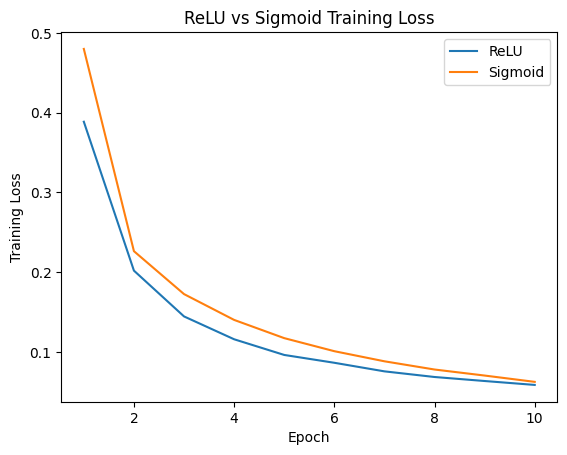

In [8]:
epochs = range(1, len(relu_loss)+1)

plt.figure()
plt.plot(epochs, relu_loss, label='ReLU')
plt.plot(epochs, sigmoid_loss, label='Sigmoid')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('ReLU vs Sigmoid Training Loss')
plt.legend()
plt.show()

## Brief Comparison

- ReLU typically converges faster and produces lower training loss.
- Sigmoid may train slower due to vanishing gradient effects.
- ReLU is generally preferred for deep neural networks.